In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("08-Linear-Regression-Models/Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop('sales', axis=1)

In [5]:
y = df['sales']

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [8]:
polynomial_converter.fit(X)

,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [9]:
poly_features = polynomial_converter.transform(X)

In [10]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [11]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
poly_features.shape

(200, 9)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
test_prediction = model.predict(X_test)

In [19]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
MAE = mean_absolute_error(y_test, test_prediction)

In [22]:
MSE = mean_squared_error(y_test, test_prediction)

In [23]:
RMSE = np.sqrt(MSE)

In [24]:
MAE

0.48967980448035886

In [25]:
RMSE

np.float64(0.6646431757269)

In [26]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [29]:
train_rmse_errors = []
test_rmse_errors = []

In [30]:
for d in range(1, 10):
    poly_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = poly_converter.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        poly_features, y, test_size=0.3, random_state=101
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

In [31]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923789987),
 np.float64(0.20953728390810636),
 np.float64(0.220468592026013),
 np.float64(0.27150074924450723),
 np.float64(0.5132041534764078)]

In [32]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269),
 np.float64(0.5803286825219469),
 np.float64(0.5077742640851456),
 np.float64(2.575819388953378),
 np.float64(9.87141360632477),
 np.float64(41.33052004954889),
 np.float64(3108.5907535489564),
 np.float64(12767.649350485362)]

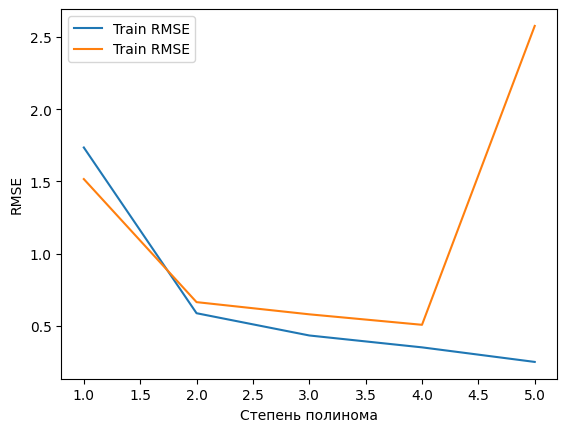

In [37]:
plt.plot(range(1,6), train_rmse_errors[:5], label='Train RMSE')
plt.plot(range(1,6), test_rmse_errors[:5], label='Train RMSE')
plt.xlabel('Степень полинома')
plt.ylabel('RMSE')
plt.legend()

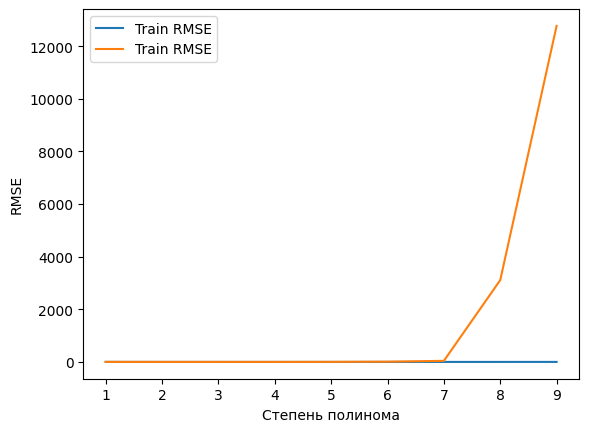

In [39]:
plt.plot(range(1,10), train_rmse_errors, label='Train RMSE')
plt.plot(range(1,10), test_rmse_errors, label='Train RMSE')
plt.xlabel('Степень полинома')
plt.ylabel('RMSE')
plt.legend()

In [41]:
final_poly_conv = PolynomialFeatures(degree=3, include_bias=False)

In [42]:
final_model = LinearRegression()

In [43]:
full_conv_X = final_poly_conv.fit_transform(X)

final_model.fit(full_conv_X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
from joblib import dump, load

In [45]:
dump(final_model, 'final_poly_model.joblib')

['final_poly_model.joblib']

In [46]:
dump(final_poly_conv, 'final_poly_conv.joblib')

['final_poly_conv.joblib']

In [48]:
loaded_conv = load("final_poly_conv.joblib")

In [49]:
loaded_model = load("final_poly_model.joblib")

In [50]:
campaign = [[149,22,12]]

In [52]:
transformed_data = loaded_conv.transform(campaign)

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [53]:
loaded_model.predict(transformed_data)

array([14.64501014])